# Prior Regularisation

The prior variance $\tau^2$ sets the diagonal of the isotropic Gaussian prior on the latent grid and trades off regularisation against expressiveness: small $\tau^2$ pulls embeddings toward the origin, while large $\tau^2$ approaches a uniform prior on the canvas. We sweep $\tau^2 \in \{0.05, 0.1, 0.25, 0.5, 1.0, 10^{6}\}$ at PCA init and the final iteration ($T=20$), with sparsity $u \in \{0.0, 0.3, 0.6, 0.9\}$ and 5 seeds per sparsity > 0.

**Research question:** How does $\tau^2$ affect fit and imputation, as well as the latent-geometry diagnostics across iterations?

A second part of the notebook studies posterior convergence: for each $\tau^2$ we replay test users answer-by-answer and ask how many answers it takes for the running posterior mean to enter the final $1\sigma$ ellipse.

In [1]:
import sys; sys.path.insert(0, "../..")
import logging; logging.getLogger("ixplore").setLevel(logging.WARNING)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Ellipse
from pathlib import Path

from src.data import DATASET_DIRS, load_dataset
from src.metrics import gaussian_moments, within_1sigma
from src.models.ixplore_wrapper import IXPLOREModel
import src.visualization as vis
import ixplore.visualization as ixplore_vis

vis.apply_defaults()

DATASET = "smartvote_2023"
TRAJ_DIR = Path(f"../../results/{DATASET}/latent_convergence")
ITER_RESULTS_DIR = Path(f"../../results/{DATASET}/iteration_effect")
MODELS_DIR = ITER_RESULTS_DIR / "models"
FIGURES_DIR = Path("../../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
data_dir = DATASET_DIRS[DATASET]

SIGMA_VALUES = [0.05, 0.1, 0.25, 0.5, 1.0, 1e6]
SIGMA_DEFAULT = 0.25
SPARSITIES = [0.0, 0.3, 0.6, 0.9]

train_metrics = pd.read_csv(ITER_RESULTS_DIR / "train_metrics.csv")
test_metrics = pd.read_csv(ITER_RESULTS_DIR / "test_metrics.csv")

trajs = {s: pd.read_csv(TRAJ_DIR / f"sigma_{s}.csv", dtype={"user": str})
         for s in SIGMA_VALUES}
trajs_scaled = {s: pd.read_csv(TRAJ_DIR / f"sigma_{s}_scaled.csv", dtype={"user": str})
                for s in SIGMA_VALUES}
K = trajs[SIGMA_DEFAULT]["k"].max()
N = trajs[SIGMA_DEFAULT]["user"].nunique()
print(f"{len(trajs)} priors x {N} users x {K + 1} steps  (scale_weights ∈ {{False, True}})")

6 priors x 1121 users x 76 steps  (scale_weights ∈ {False, True})


## How does $\tau^2$ affect fit and imputation?

We restrict to PCA init and the final iteration ($T=20$) so that the variation visible in each plot is attributable to $\tau^2$ alone.

In [2]:
ITER_FINAL = 20
tr_f = train_metrics[(train_metrics["init"] == "pca") & (train_metrics["iteration"] == ITER_FINAL)]
te_f = test_metrics[(test_metrics["init"] == "pca") & (test_metrics["iteration"] == ITER_FINAL)]
print(f"final-iter train rows: {len(tr_f)}, test rows: {len(te_f)}")

final-iter train rows: 96, test rows: 96


### Tradeoff phase diagrams across iterations

For each $\tau^2$ at PCA initialisation, trace one iteration trajectory ($T = 0 \to 20$) in two trade-off planes. Each $\tau^2$ gets one viridis colour shared across panels; marker size grows with $T$; the arrow points from $T=0$ to $T=20$.

**Sparsity convention.** Both panels are computed at PCA init.
- **Left** (boundary fraction × fit MAE): both metrics come from the *train* split at $u = 0$, i.e. the candidate matrix as observed, with no artificial masking.
- **Right** (distortion × test-impute MAE): distortion is computed on the train embedding at $u = 0$ from a synthetic $30 \times 30$ grid re-embedded into the trained latent space. Test-impute MAE is averaged over the test split's masked sparsity grid $u \in \{0.3, 0.6, 0.9\}$ (5 seeds each), since test-impute is undefined when nothing is masked.

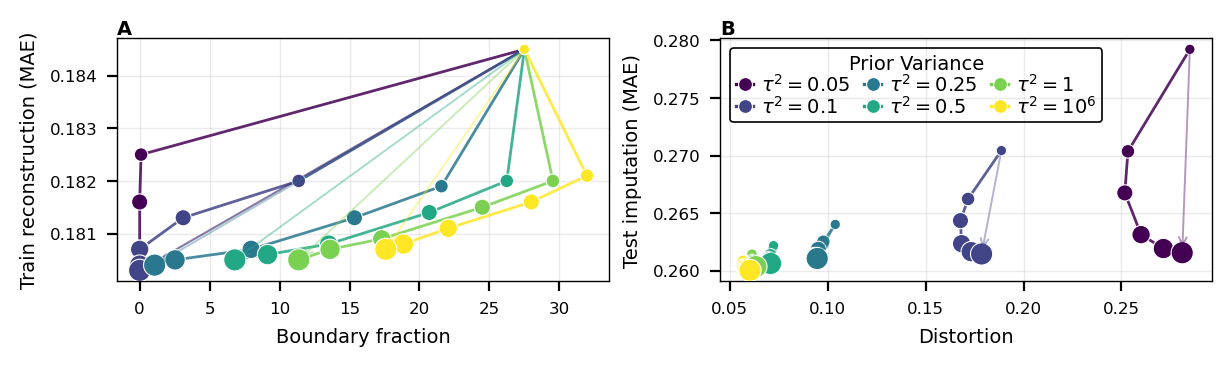

In [3]:
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

# Aggregate per (sigma, iteration) at PCA init, u=0; prediction metrics averaged over seeds.
train_pca0 = (train_metrics[(train_metrics["init"] == "pca")
                            & (train_metrics["sparsity"] == 0.0)]
              .groupby(["sigma", "iteration"])
              [["fit_mae", "boundary", "distortion_mean"]]
              .mean()
              .reset_index())

# Test-impute MAE: held-out users at u > 0 (artificial mask), averaged over the
# sparsity grid and seeds for one number per (sigma, iteration).
test_impute = (test_metrics[(test_metrics["init"] == "pca")
                            & (test_metrics["sparsity"] > 0.0)]
               .groupby(["sigma", "iteration"])
               ["impute_mae"]
               .mean()
               .reset_index())

merged = train_pca0.merge(test_impute, on=["sigma", "iteration"])

sigma_cmap = plt.cm.viridis
sigma_color = {s: sigma_cmap(i / (len(SIGMA_VALUES) - 1))
               for i, s in enumerate(SIGMA_VALUES)}
ITER_GRID = sorted(merged["iteration"].unique())
iter_size = {it: 14 + 10 * rank for rank, it in enumerate(ITER_GRID)}


def add_phase(ax, x_col, y_col, x_scale=1.0):
    for s in SIGMA_VALUES:
        traj = merged[merged["sigma"] == s].sort_values("iteration")
        c = sigma_color[s]
        x = traj[x_col].values * x_scale
        y = traj[y_col].values
        ax.plot(x, y, "-", color=c, lw=1.0, alpha=0.85, zorder=2)
        sizes = traj["iteration"].map(iter_size).values
        ax.scatter(x, y, s=sizes, color=c, edgecolor="white", linewidth=0.4,
                   zorder=3)
        ax.annotate("", xy=(x[-1], y[-1]), xytext=(x[0], y[0]),
                    arrowprops=dict(arrowstyle="->", color=c, alpha=0.4, lw=0.7))


fig, (axL, axR) = plt.subplots(1, 2, figsize=vis.figsize(width_frac=1.0, aspect=0.28))

add_phase(axL, x_col="boundary", y_col="fit_mae", x_scale=100.0)
axL.set_xlabel("Boundary fraction")
axL.set_ylabel("Train reconstruction (MAE)")

add_phase(axR, x_col="distortion_mean", y_col="impute_mae")
axR.set_xlabel("Distortion")
axR.set_ylabel("Test imputation (MAE)")

# Consistent grid; per-panel tick spacing matched to each metric range.
for ax in (axL, axR):
    ax.grid(True, alpha=0.25, linewidth=0.5)
axL.yaxis.set_major_locator(MultipleLocator(0.001))
axL.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
axR.yaxis.set_major_locator(MultipleLocator(0.005))
axR.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

# Legend embedded in the right panel.
sigma_handles = [plt.Line2D([0], [0], marker="o", color=sigma_color[s], lw=1.2,
                            markersize=5, markeredgecolor="white",
                            markeredgewidth=0.4,
                            label=rf"$\tau^2={vis.fmt_sigma(s)}$") for s in SIGMA_VALUES]
legR = axR.legend(handles=sigma_handles, loc="upper left",
                  title=r"Prior Variance",
                  handlelength=0.9, borderpad=0.3, labelspacing=0.0,
                  handletextpad=0.4, framealpha=1.0, ncols=3, columnspacing=0.7)
legR.get_frame().set_edgecolor("black")
legR.get_frame().set_linewidth(0.6)

fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=axL.transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=axR.transAxes)
fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95], w_pad=0.7)
fig.savefig(FIGURES_DIR / f"prior_phase_{DATASET}.pdf")
plt.show()

### Three-prior embedding visual (publication)

Restricted to three representative priors — $\tau^2 \in \{0.05, 0.25, 10^6\}$ — and sized for the report. Each panel shows the candidate embedding coloured by party, with the per-panel boundary fraction and total variance annotated for reference.

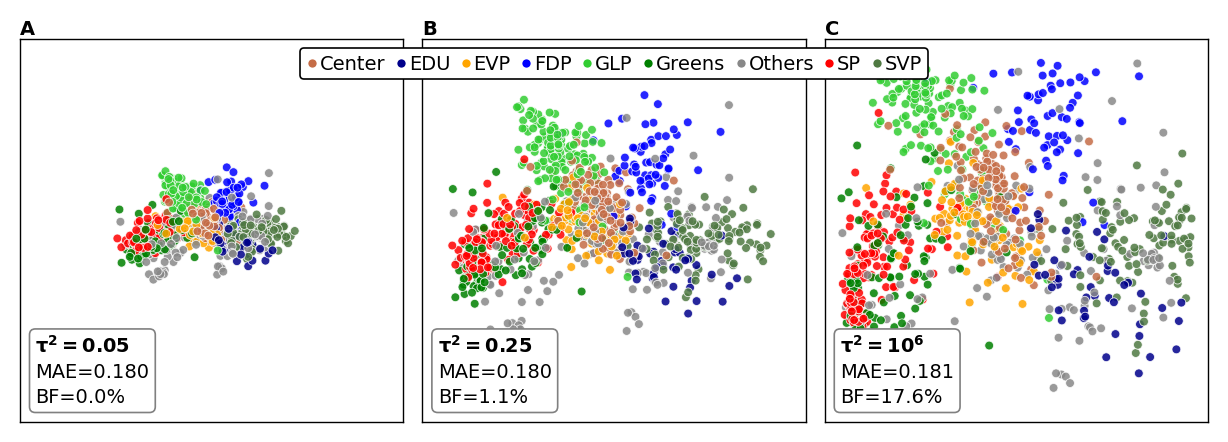

In [4]:
PRIOR_PANELS = [0.05, SIGMA_DEFAULT, 1e6]

info = pd.read_csv(data_dir / "candidates_information.csv", index_col=0)
party_colors = info.groupby("party")["color"].first().to_dict()

geom_lookup = (tr_f[tr_f["sparsity"] == 0.0]
               .groupby("sigma")[["fit_mae", "boundary"]]
               .mean())

fig, axes = plt.subplots(1, 3, figsize=vis.figsize(width_frac=1.0, aspect=0.35))

for ax, sigma in zip(axes, PRIOR_PANELS):
    name = f"sigma_{sigma}_pca_sp_0.0_iter_{ITER_FINAL}"
    emb = pd.read_csv(MODELS_DIR / name / "embedding.csv", index_col=0)
    emb = emb.copy()
    emb.iloc[:, 0] = -emb.iloc[:, 0]
    panel_colors = (info.loc[emb.index.intersection(info.index), "party"]
                        .map(party_colors).values)
    ixplore_vis.plot_embedding(emb, colors=panel_colors, ax=ax, s=10, alpha=0.85,
                               edgecolors="white", lw=0.3)

    fit_mae = geom_lookup.loc[sigma, "fit_mae"]
    boundary = geom_lookup.loc[sigma, "boundary"]
    bbox = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=1.0,
                edgecolor="0.5", linewidth=0.6)
    ax.text(0.04, 0.04,
            f"$\\bf{{\\tau^2={vis.fmt_sigma(sigma)}}}$\n"
            f"MAE={fit_mae:.3f}\n"
            f"BF={boundary * 100:.1f}%",
            transform=ax.transAxes, ha="left", va="bottom",
            linespacing=1.4, bbox=bbox)
    ixplore_vis.clean_axis(ax, limits=(-1, 1))

# Party legend inside the leftmost panel: framed, white background, tight spacing.
party_handles = [plt.Line2D([0], [0], marker="o", color="w",
                            markerfacecolor=party_colors[p], markersize=4,
                            label=p)
                 for p in sorted(party_colors)]
leg = axes[1].legend(handles=party_handles, loc="upper center",
                     ncol=9, fontsize=7,
                     handlelength=0.6, handletextpad=0.1,
                     columnspacing=0.5, labelspacing=0.2,
                     borderpad=0.3, framealpha=1.0, facecolor="white")
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(0.6)

axes[1].set_zorder(axes[0].get_zorder() + 1)
axes[1].set_zorder(axes[2].get_zorder() + 1)
axes[1].patch.set_visible(False)
leg.set_zorder(20)
fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=axes[0].transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=axes[1].transAxes)
fig.text(-0,1, 'C', va='bottom', ha='left', weight='bold', transform=axes[2].transAxes)
fig.subplots_adjust(top=0.95, bottom=0.005, left=0.005, right=0.995, wspace=0.05)
fig.savefig(FIGURES_DIR / f"prior_embeddings_{DATASET}.pdf")
plt.show()

## How fast does the posterior converge under each prior?

For every $\tau^2$ we load the fully-fit candidate model (PCA init, sparsity 0, $T=20$) and replay each test user answer-by-answer in natural item order. Trajectory data are precomputed by `python -m src.scripts.run_latent_convergence`; the cells below only load CSVs and plot.

### Posterior trajectory and convergence CDF

**Left.** Test user whose final posterior mean lies furthest from the origin (under default $\tau^2=0.25$). Background contour: posterior over the latent space *after the user has answered 15 of 75 items* (orange = high probability). Black dots: running posterior mean at every $k$, in answer order. Dashed black ellipse: 1$\sigma$ contour of the moment-matched Gaussian fit to the **final** posterior (all 75 items) — the spread of latent positions still consistent with the user's full reactions.

**Right.** CDF of "first $k$ at which the running posterior mean enters the final 1$\sigma$ ellipse" across all test users, $\tau^2=0.25$, `scale_weights=False`. Dotted lines mark the 50th- and 95th-percentile crossings.

**Table.** For each $(\tau^2, \texttt{scale\_weights})$ pair: mean, median, 95th-percentile of $k$-to-1$\sigma$, and a normalised area-under-the-CDF (AUC $= 1 - \overline{k_\star}/K$, higher = faster convergence).

furthest test user (τ²=0.25): 1563348 (||μ_final||=0.779, k-to-1σ=30)


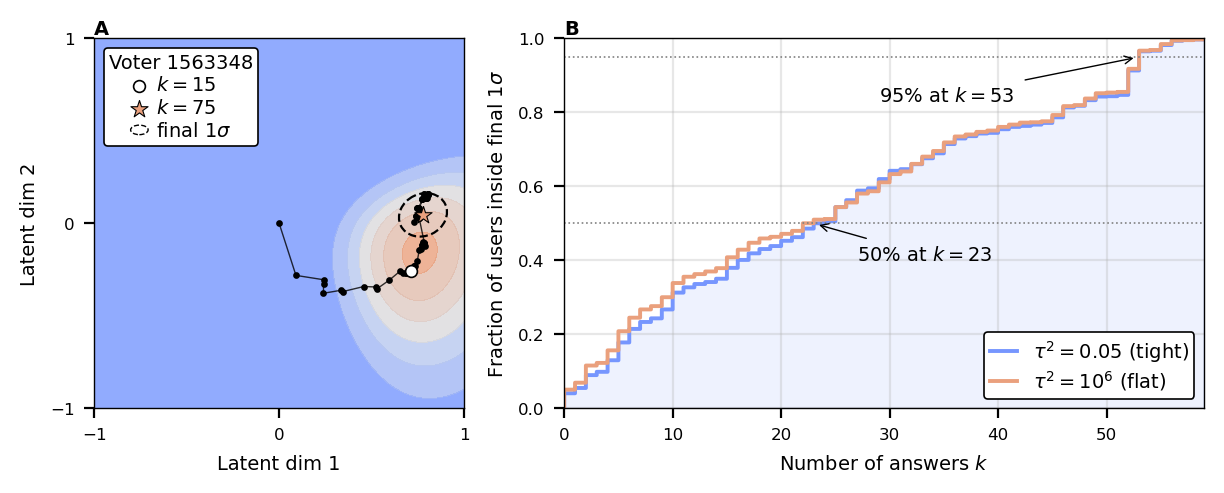

In [5]:
def first_k_table(t):
    Kt = t["k"].max()
    return (t[t["in_1sigma"]].groupby("user")["k"].min()
            .reindex(t["user"].unique()).fillna(Kt).astype(int))

per_prior_first_k = {s: first_k_table(t) for s, t in trajs.items()}
per_prior_first_k_scaled = {s: first_k_table(t) for s, t in trajs_scaled.items()}

# Worst user under the default prior = furthest final posterior mean from origin.
default_traj = trajs[SIGMA_DEFAULT]
final_rows = default_traj[default_traj["k"] == K].copy()
final_rows["dist"] = np.hypot(final_rows["mean_x"], final_rows["mean_y"])
worst_user = final_rows.loc[final_rows["dist"].idxmax(), "user"]
worst_dist = float(final_rows["dist"].max())
worst_k_to_1sigma = int(per_prior_first_k[SIGMA_DEFAULT].loc[worst_user])
print(f"furthest test user (τ²={SIGMA_DEFAULT}): {worst_user} "
      f"(||μ_final||={worst_dist:.3f}, k-to-1σ={worst_k_to_1sigma})")

dataset = load_dataset(DATASET, test_fraction=0.15)
test = dataset.test_reactions

worst_wrapper = IXPLOREModel.load(MODELS_DIR / f"sigma_{SIGMA_DEFAULT}_pca_sp_0.0_iter_20")
worst_inner = worst_wrapper._model
worst_answers = test.loc[worst_user]
worst_final_post = worst_inner.compute_posteriors(worst_answers)
worst_final_mean, worst_final_cov = gaussian_moments(worst_final_post, worst_inner.X)
worst_path = (default_traj[default_traj["user"] == worst_user]
              .sort_values("k")[["mean_x", "mean_y"]].to_numpy())

K_SNAP = 15

# Place axes by hand. The left panel uses set_aspect('equal') on square data,
# so its allocated box must also be square: panel_h_in == left_w_in. Otherwise
# the left axes shrinks to a square inside a taller box and the two panels end
# up unequal heights. fig_h is derived from the panel plus margins, so the
# saved box exactly contains the panels, the bold letters (margin_t), and the
# x-labels (margin_b).
fig_w = 6.0
left_w_in, right_w_in = 1.85, 3.2
margin_l, margin_b, margin_t = 0.4, 0.35, 0.12
gap_in = 0.5
panel_h_in = left_w_in
fig_h = panel_h_in + margin_b + margin_t

fig = plt.figure(figsize=(fig_w, fig_h))
axL = fig.add_axes([margin_l / fig_w,
                    margin_b / fig_h,
                    left_w_in / fig_w,
                    panel_h_in / fig_h])
axR = fig.add_axes([(margin_l + left_w_in + gap_in) / fig_w,
                    margin_b / fig_h,
                    right_w_in / fig_w,
                    panel_h_in / fig_h])

# ── Left panel ───────────────────────────────────────────────────────────────
n_collections_before = len(axL.collections)
ixplore_vis.plot_posterior(worst_inner, worst_answers.iloc[:K_SNAP], ax=axL,
                           add_bar=False, cmap=ixplore_vis.colormap)
for child in axL.collections[n_collections_before:]:
    if isinstance(child, plt.matplotlib.collections.PathCollection) and \
       child.get_offsets().shape[0] == 1:
        child.remove()

# Trajectory: thin connected line + tiny black dots
axL.plot(worst_path[:, 0], worst_path[:, 1], color="black", lw=0.5, alpha=0.8,
         zorder=4)
axL.scatter(worst_path[:, 0], worst_path[:, 1], color="black",
            s=2, zorder=5)
# Highlights: white circle at k=15, coloured star (on top) at the final mean
axL.scatter(*worst_path[K_SNAP], facecolor="white", edgecolor="black",
            s=18, lw=0.6, zorder=6, label=f"$k={K_SNAP}$")
axL.scatter(*worst_final_mean, marker="*", facecolor=ixplore_vis.orange_hex,
            edgecolor="black", s=42, lw=0.4, zorder=8,
            label=f"$k={K}$")
ellipse_handle = vis.make_ellipse(worst_final_mean, worst_final_cov, fill=False,
                                   edgecolor="black", lw=0.8, ls="--", zorder=7,
                                   label=r"final 1$\sigma$")
axL.add_patch(ellipse_handle)

axL.set_xlim(*worst_inner.limits); axL.set_ylim(*worst_inner.limits)
axL.set_aspect("equal", adjustable="box")
axL.set_xticks([-1, 0, 1]); axL.set_yticks([-1, 0, 1])
axL.set_xlabel("Latent dim 1"); axL.set_ylabel("Latent dim 2")
axL.grid(False)
legL = axL.legend(loc="upper left", title=f"Voter {worst_user}",
                  handlelength=0.9, borderpad=0.25,
                  labelspacing=0.2, handletextpad=0.4, framealpha=1.0,
                  facecolor="white",
                  handler_map={Ellipse: vis.ellipse_legend_handler()})
legL.get_frame().set_edgecolor("black")
legL.get_frame().set_linewidth(0.6)

# ── Right panel: overlay tightest- and weakest-prior CDFs ────────────────────
def cdf_for(table):
    sk = np.sort(table.values)
    return sk, np.arange(1, len(sk) + 1) / len(sk)

SIGMA_TIGHT, SIGMA_FLAT = 0.05, 1e6
sk_tight, cdf_tight = cdf_for(per_prior_first_k[SIGMA_TIGHT])
sk_flat, cdf_flat = cdf_for(per_prior_first_k[SIGMA_FLAT])

axR.step(sk_tight, cdf_tight, color=ixplore_vis.blue_hex, lw=1.4, where="post",
         label=rf"$\tau^2=0.05$ (tight)")
axR.step(sk_flat, cdf_flat, color=ixplore_vis.orange_hex, lw=1.4, where="post",
         label=rf"$\tau^2=10^6$ (flat)")
axR.fill_between(sk_tight, 0, cdf_tight, step="post", alpha=0.12,
                 color=ixplore_vis.blue_hex)

axR.axhline(0.5, color="gray", ls=":", lw=0.6)
axR.axhline(0.95, color="gray", ls=":", lw=0.6)

# Annotate using the tight-prior CDF
k50 = int(sk_tight[np.searchsorted(cdf_tight, 0.5)])
k95 = int(sk_tight[np.searchsorted(cdf_tight, 0.95)])
axR.annotate(f"50% at $k={k50}$", xy=(k50, 0.5), xytext=(k50 + 4, 0.40),
             arrowprops=dict(arrowstyle="->", lw=0.5))
axR.annotate(f"95% at $k={k95}$", xy=(k95, 0.95), xytext=(k95 - 24, 0.83),
             arrowprops=dict(arrowstyle="->", lw=0.5))

# Trim x-axis to where the CDFs reach 1 (no whitespace to the right).
k_max_reach = int(max(sk_tight[-1], sk_flat[-1]))
axR.set_xlim(0, k_max_reach); axR.set_ylim(0, 1.0)
axR.set_xlabel("Number of answers $k$")
axR.set_ylabel(r"Fraction of users inside final 1$\sigma$")
legR = axR.legend(loc="lower right", handlelength=1.4, borderpad=0.3,
                  labelspacing=0.25, framealpha=1.0, facecolor="white")
legR.get_frame().set_edgecolor("black")
legR.get_frame().set_linewidth(0.6)
fig.text(-0, 1, 'A', va='bottom', ha='left', weight='bold', transform=axL.transAxes)
fig.text(-0, 1, 'B', va='bottom', ha='left', weight='bold', transform=axR.transAxes)
fig.savefig(FIGURES_DIR / f"posterior_trajectory_{DATASET}.pdf")
plt.show()

In [6]:
def summarise(table, sigma, scale_label, K):
    fk = table.values
    return {
        "sigma^2": sigma,
        "scale_weights": scale_label,
        "mean k": fk.mean().round(1),
        "median k": int(np.median(fk)),
        "k95": int(np.quantile(fk, 0.95)),
        "AUC": round(1 - fk.mean() / K, 3),
    }

rows = []
for s in SIGMA_VALUES:
    rows.append(summarise(per_prior_first_k[s], s, False, K))
    rows.append(summarise(per_prior_first_k_scaled[s], s, True, K))

summary = pd.DataFrame(rows)
summary

,sigma^2,scale_weights,mean k,median k,k95,AUC
0,0.05,False,25.0,23,53,0.667
1,0.05,True,25.8,25,53,0.656
2,0.10,False,25.0,24,53,0.667
3,0.10,True,25.8,25,53,0.656
4,0.25,False,24.8,23,53,0.670
5,0.25,True,25.6,24,53,0.658
6,0.50,False,24.5,23,53,0.674
7,0.50,True,25.4,23,53,0.661
8,1.00,False,24.4,23,53,0.674
9,1.00,True,25.1,23,53,0.665
